In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

import pandas as pd
import numpy as np
import networkx as nx


file = Path("../data/repeated_10_scale_250/100206_repeated10_scale250.graphml")

node_num_cols = [
    "dn_position_x", "dn_position_y", "dn_position_z", "dn_correspondence_id"
]

edge_num_cols = [
    "fiber_length_mean", "FA_mean", "number_of_fibers"
]

G = nx.read_graphml(file)

node_records = []
for node_id, attrs in G.nodes(data=True):
    node_records.append({
        "file": file.name,
        "path": str(file),
        "node_id": node_id,
        **attrs
    })

nodes_df = pd.DataFrame(node_records)

for col in node_num_cols:
    if col in nodes_df.columns:
        nodes_df[col] = pd.to_numeric(nodes_df[col], errors="coerce")

edge_records = []
for u, v, attrs in G.edges(data=True):
    edge_records.append({
        "file": file.name,
        "path": str(file),
        "source": u,
        "target": v,
        **attrs
    })

edges_df = pd.DataFrame(edge_records)

for col in edge_num_cols:
    if col in edges_df.columns:
        edges_df[col] = pd.to_numeric(edges_df[col])


display(nodes_df.head())
display(edges_df.head())

,file,path,node_id,dn_position_x,dn_position_y,dn_position_z,dn_correspondence_id,dn_region,dn_fsname,dn_name,dn_hemisphere
0,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,1,36.000000,74.143590,7.584615,1,cortical,lateralorbitofrontal_1,rh.lateralorbitofrontal_1,right
1,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,29.917241,78.565517,13.675862,2,cortical,lateralorbitofrontal_2,rh.lateralorbitofrontal_2,right
2,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,3,28.670673,80.062500,7.425481,3,cortical,lateralorbitofrontal_3,rh.lateralorbitofrontal_3,right
3,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,4,36.979933,79.662207,7.926421,4,cortical,lateralorbitofrontal_4,rh.lateralorbitofrontal_4,right
4,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,5,37.913043,85.681159,7.526570,5,cortical,lateralorbitofrontal_5,rh.lateralorbitofrontal_5,right


,file,path,source,target,fiber_length_mean,FA_mean,number_of_fibers
0,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,224,36.699456,0.163246,13.000
1,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,225,20.892134,0.186631,40.250
2,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,226,14.545893,0.230742,261.250
3,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,227,22.152100,0.271936,41.125
4,100206_repeated10_scale250.graphml,../data/repeated_10_scale_250/100206_repeated1...,2,222,12.405001,0.294189,2.625


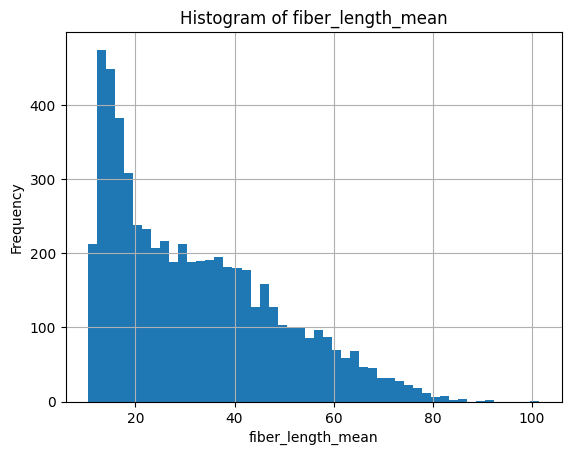

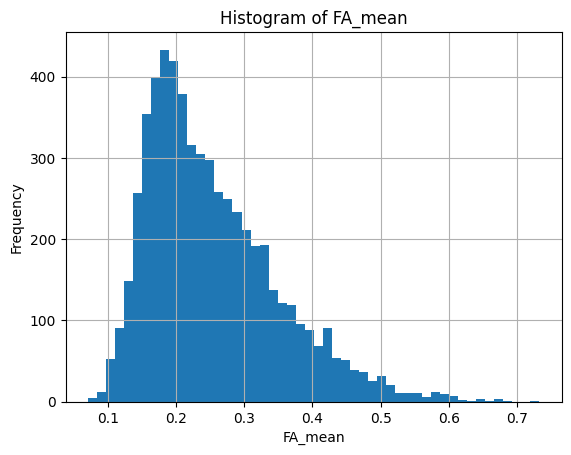

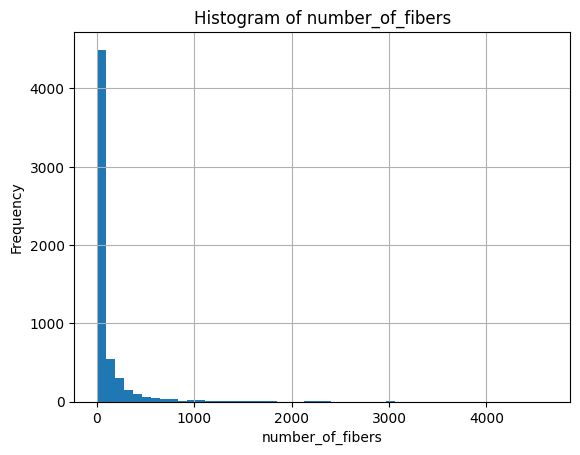

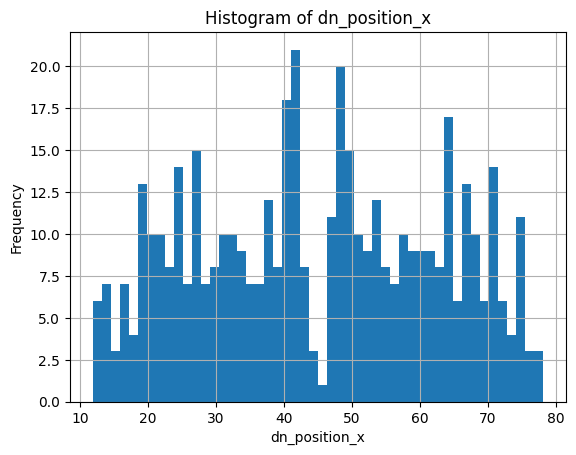

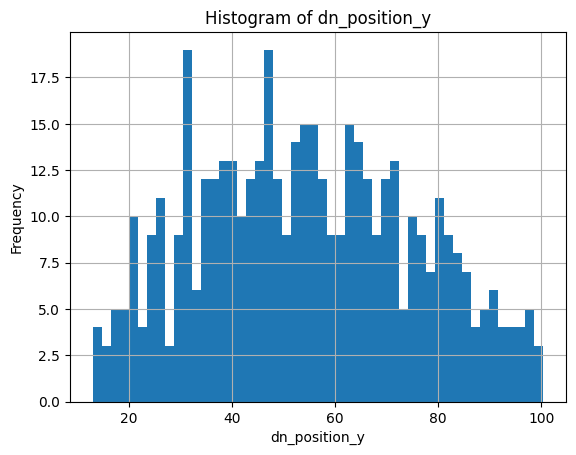

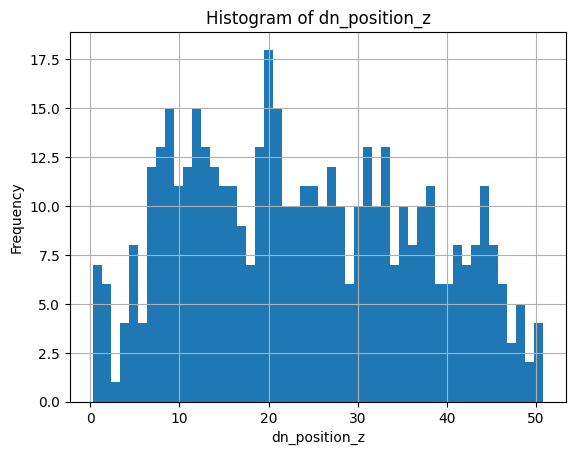

In [2]:
# --- EDGE FEATURES ---
edge_cols = ["fiber_length_mean", "FA_mean", "number_of_fibers"]

for col in edge_cols:
    if col in edges_df.columns:
        plt.figure()
        edges_df[col].dropna().hist(bins=50)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


# --- NODE FEATURES ---
node_cols = ["dn_position_x", "dn_position_y", "dn_position_z"]

for col in node_cols:
    if col in nodes_df.columns:
        plt.figure()
        nodes_df[col].dropna().hist(bins=50)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

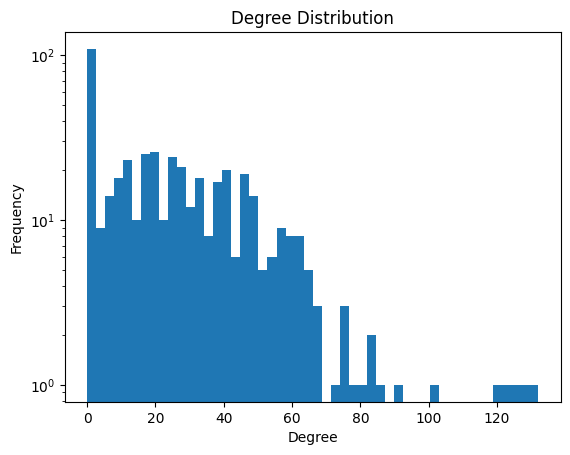

In [3]:
degrees = [deg for _, deg in G.degree()]

plt.figure()
plt.hist(degrees, bins=50)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.yscale('log')
plt.show()

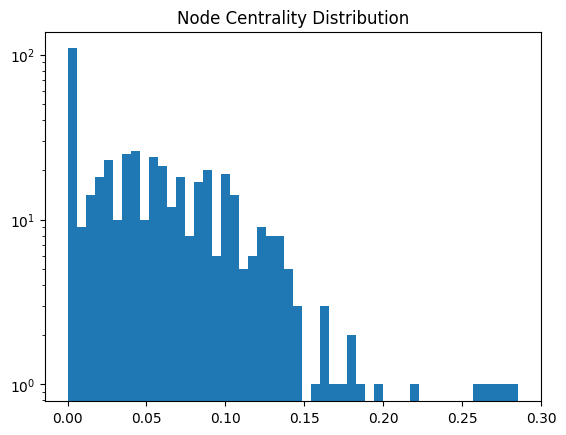

In [4]:
centrality = nx.degree_centrality(G)

plt.hist(list(centrality.values()), bins=50)
plt.title("Node Centrality Distribution")
plt.yscale('log')
plt.show()

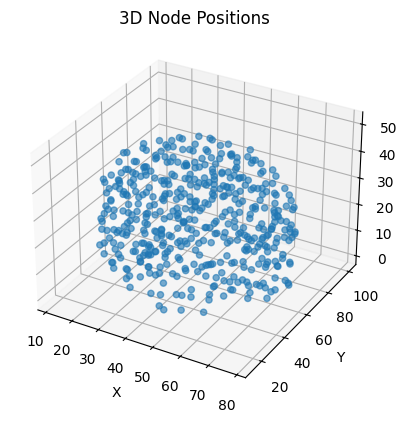

In [5]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(
    nodes_df["dn_position_x"],
    nodes_df["dn_position_y"],
    nodes_df["dn_position_z"],
    alpha=0.6
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Node Positions")

plt.show()

In [6]:
color_arg = "cluster" if "cluster" in nodes_df.columns else None

fig = px.scatter_3d(
    nodes_df,
    x="dn_position_x",
    y="dn_position_y",
    z="dn_position_z",
    color=color_arg,
)

fig.show()

## 1. Interactive 3D Brain Connectome (Plotly)


In [7]:
# Ensure positions are floats
nodes_df['dn_position_x'] = nodes_df['dn_position_x'].astype(float)
nodes_df['dn_position_y'] = nodes_df['dn_position_y'].astype(float)
nodes_df['dn_position_z'] = nodes_df['dn_position_z'].astype(float)

# Create a trace for the nodes
node_trace = go.Scatter3d(
    x=nodes_df['dn_position_x'],
    y=nodes_df['dn_position_y'],
    z=nodes_df['dn_position_z'],
    mode='markers',
    hoverinfo='text',
    text=nodes_df['dn_name'],
    marker=dict(
        size=5,
        color=nodes_df['dn_region'].astype('category').cat.codes,
        colorscale='Viridis',
        opacity=0.8
    )
)

edge_x = []
edge_y = []
edge_z = []

# To make it efficient, we iterate and plot only edges with > some fiber count
threshold = np.percentile(edges_df['number_of_fibers'], 95)
strong_edges = edges_df[edges_df['number_of_fibers'] > threshold]

for _, edge in strong_edges.iterrows():
    source_node = nodes_df[nodes_df['node_id'] == edge['source']]
    target_node = nodes_df[nodes_df['node_id'] == edge['target']]
    if not source_node.empty and not target_node.empty:
        edge_x.extend([source_node['dn_position_x'].values[0], target_node['dn_position_x'].values[0], None])
        edge_y.extend([source_node['dn_position_y'].values[0], target_node['dn_position_y'].values[0], None])
        edge_z.extend([source_node['dn_position_z'].values[0], target_node['dn_position_z'].values[0], None])

edge_trace = go.Scatter3d(
    x=edge_x,
    y=edge_y,
    z=edge_z,
    mode='lines',
    line=dict(color='rgba(150, 150, 150, 0.5)', width=1),
    hoverinfo='none'
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title=f"3D Brain Connectome (Top 5% Edges by Fiber Count)",
    scene=dict(
        xaxis=dict(showbackground=False, visible=False),
        yaxis=dict(showbackground=False, visible=False),
        zaxis=dict(showbackground=False, visible=False)
    )
)
fig.show()


## 2. Structural Connectivity Heatmap (Seaborn)


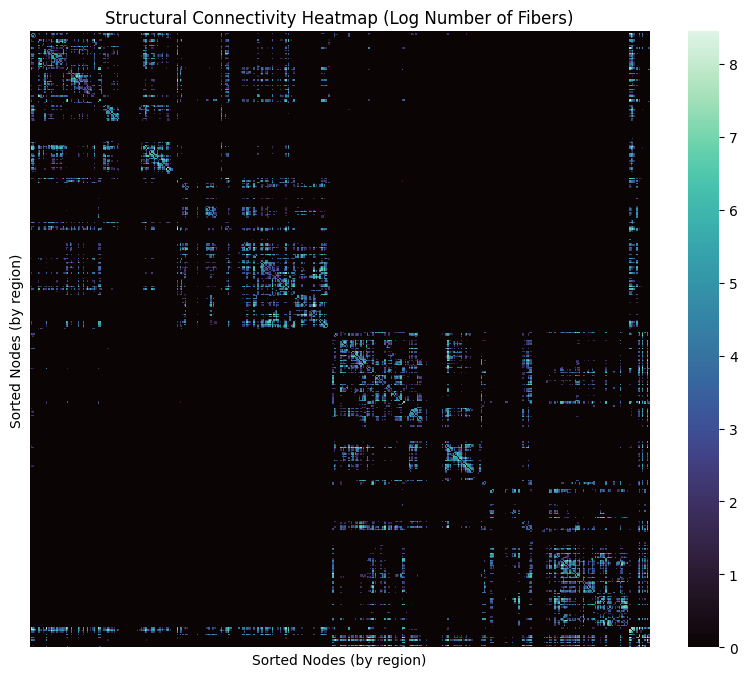

In [8]:
# Create Adjacency Matrix
unique_nodes = nodes_df['node_id'].unique()
node_to_idx = {node: idx for idx, node in enumerate(unique_nodes)}
num_nodes = len(unique_nodes)

adj_matrix = np.zeros((num_nodes, num_nodes))

for _, edge in edges_df.iterrows():
    if edge['source'] in node_to_idx and edge['target'] in node_to_idx:
        u = node_to_idx[edge['source']]
        v = node_to_idx[edge['target']]
        adj_matrix[u, v] = edge['number_of_fibers']
        adj_matrix[v, u] = edge['number_of_fibers']  # Assuming undirected for the matrix display

# Sort nodes by region to see clustering
nodes_df_sorted = nodes_df.sort_values(by='dn_region')
sorted_indices = [node_to_idx[n] for n in nodes_df_sorted['node_id'] if n in node_to_idx]
adj_matrix_sorted = adj_matrix[np.ix_(sorted_indices, sorted_indices)]

plt.figure(figsize=(10, 8))
sns.heatmap(np.log1p(adj_matrix_sorted), cmap='mako', xticklabels=False, yticklabels=False)
plt.title('Structural Connectivity Heatmap (Log Number of Fibers)')
plt.xlabel('Sorted Nodes (by region)')
plt.ylabel('Sorted Nodes (by region)')
plt.show()


## 3. Fiber Length vs. FA Mean vs. Connectivity Strength (Plotly)


In [9]:
import plotly.express as px

# Scatter plot of Fiber Length vs FA Mean
fig = px.scatter(
    edges_df, 
    x='fiber_length_mean', 
    y='FA_mean', 
    size='number_of_fibers', 
    color='number_of_fibers',
    hover_data=['source', 'target'],
    title="Fiber Length vs FA Mean (size & color = number of fibers)",
    color_continuous_scale='plasma'
)
fig.update_layout(
    xaxis_title="Mean Fiber Length",
    yaxis_title="Mean Fractional Anisotropy (FA)",
)
fig.show()
